# 07 — Handmade features + K-Means

Пайплайн: `Dataloader` → окна с индикаторами → `HandmadeEmbedder` (16 статистик на окно) → **KMeansClusterer** → интерпретация через `cluster_analysis` и `ClusterAnalyzer`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from embeddings.Handmade_embedder import HandmadeEmbedder
from clustering.kmeans import KMeansClusterer
from clustering.cluster_analysis import elbow_scores, plot_elbow, plot_clusters_2d, cluster_stats
from clustering.cluster_analyze import ClusterAnalyzer

WINDOW_SIZE = 5
STEP = 5
RANDOM_STATE = 42
K_RANGE = range(2, 20, 2)
np.random.seed(RANDOM_STATE)

print(f"Tickers: {len(TICKERS)}  |  Window: {WINDOW_SIZE}  |  Step: {STEP}")
# print(f"Handmade features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

245
Tickers: 245  |  Window: 5  |  Step: 5


In [2]:
loader = Dataloader()

FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]
CLOSE_IDX = FEATURE_COLS.index("close")

dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=WINDOW_SIZE,
    step_size=STEP,
    feature_cols=FEATURE_COLS,
    add_indicators=True,
    path="../../src/data/moex_candles",
)
print(f"Loaded {len(dataset)} / {len(TICKERS)} tickers")

X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Loaded 236 / 245 tickers
X_train: (116685, 5, 18)  y_train: (116685,)
X_val:   (22292, 5, 18)    y_val:   (22292,)
X_test:  (16904, 5, 18)   y_test:  (16904,)


In [3]:
embedder = HandmadeEmbedder()

train_emb_raw = embedder.transform(X_train)
val_emb_raw   = embedder.transform(X_val)
test_emb_raw  = embedder.transform(X_test)

# Убираем строки с NaN/Inf (появляются на вырожденных окнах)
def clean_mask(emb: np.ndarray) -> np.ndarray:
    return np.isfinite(emb).all(axis=1)

mask_tr   = clean_mask(train_emb_raw)
mask_val  = clean_mask(val_emb_raw)
mask_test = clean_mask(test_emb_raw)

train_emb = train_emb_raw[mask_tr]
val_emb   = val_emb_raw[mask_val]
test_emb  = test_emb_raw[mask_test]

X_train, y_train = X_train[mask_tr],   y_train[mask_tr]
X_val,   y_val   = X_val[mask_val],     y_val[mask_val]
X_test,  y_test  = X_test[mask_test],   y_test[mask_test]

print(f"Train: {train_emb_raw.shape[0]:,} → {train_emb.shape[0]:,}  (dropped {(~mask_tr).sum():,})")
print(f"Val:   {val_emb_raw.shape[0]:,} → {val_emb.shape[0]:,}  (dropped {(~mask_val).sum():,})")
print(f"Test:  {test_emb_raw.shape[0]:,} → {test_emb.shape[0]:,}  (dropped {(~mask_test).sum():,})")

Train: 116,685 → 116,514  (dropped 171)
Val:   22,292 → 22,291  (dropped 1)
Test:  16,904 → 16,902  (dropped 2)


In [4]:
# # Диагностика мультиколлинеарности (до elbow / KMeans)
# # sign_changes_norm в эмбеддере нет — ниже считаем синтетическую долю смен знака по тем же pct_ret.

# CORR_THRESH = 0.85

# emb_df = pd.DataFrame(train_emb, columns=FEATURE_NAMES)
# C = emb_df.corr()

# fig, ax = plt.subplots(figsize=(10, 8))
# im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
# ax.set_xticks(range(len(FEATURE_NAMES)))
# ax.set_yticks(range(len(FEATURE_NAMES)))
# ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
# ax.set_yticklabels(FEATURE_NAMES)
# plt.colorbar(im, ax=ax)
# ax.set_title("Корреляции фич HandmadeEmbedder (train_emb)")
# plt.tight_layout()
# plt.show()

# pairs = []
# n = len(FEATURE_NAMES)
# for i in range(n):
#     for j in range(i + 1, n):
#         r = float(C.iloc[i, j])
#         if abs(r) >= CORR_THRESH:
#             pairs.append((FEATURE_NAMES[i], FEATURE_NAMES[j], r))
# pairs.sort(key=lambda x: -abs(x[2]))
# print(f"Пары с |r| ≥ {CORR_THRESH}:")
# for a, b, r in pairs:
#     print(f"  {a} ↔ {b}:  r = {r:.4f}")
# if not pairs:
#     print("  (нет таких пар)")

# # Та же формула pct_ret, что в Handmade_embedder (close-канал)
# close_w = X_train[:, :, CLOSE_IDX].astype(np.float64)
# prev_w = close_w[:, :-1]
# curr_w = close_w[:, 1:]
# with np.errstate(divide="ignore", invalid="ignore"):
#     pct_w = (curr_w - prev_w) / (np.abs(prev_w) + 1e-8)
# pct_w = np.where(np.isfinite(pct_w), pct_w, 0.0)
# sgn = np.sign(pct_w)
# sign_change_rate = np.mean(sgn[:, 1:] != sgn[:, :-1], axis=1)
# aci = train_emb[:, FEATURE_NAMES.index("autocorr_lag1")]
# mask_sc = np.isfinite(sign_change_rate) & np.isfinite(aci)
# if mask_sc.sum() > 10:
#     r_sc_ac = np.corrcoef(sign_change_rate[mask_sc], aci[mask_sc])[0, 1]
#     print(f"\nСинтет. sign_change_rate ↔ autocorr_lag1:  r = {r_sc_ac:.4f}")
#     print("  (обычно r < 0: сильная автокорреляция → реже меняется знак доходности)")
# else:
#     print("Недостаточно точек для корреляции sign_change vs autocorr.")

Elbow / silhouette: все 116,514 окон (ELBOW_SUBSAMPLE is None — без подвыборки)
Фактически в plot_elbow передаётся n = 116,514


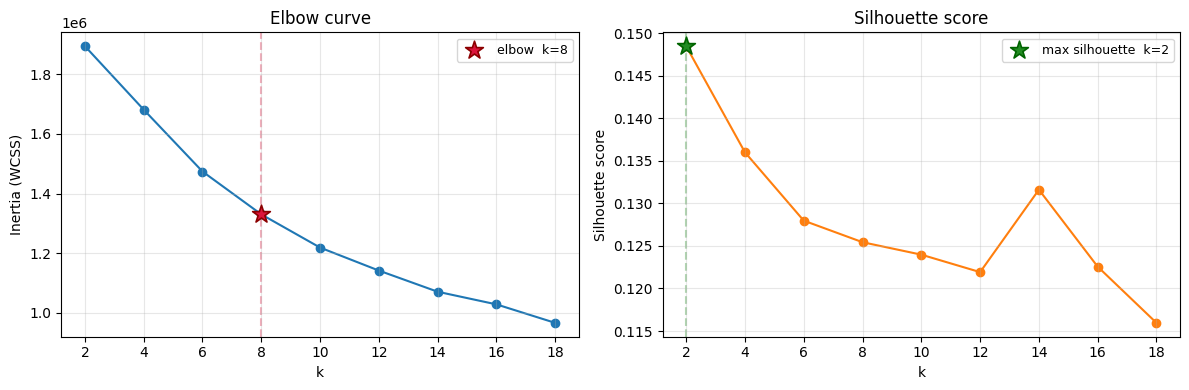


Рекомендуемое k по max silhouette в 2…18: 2
[0.14847308 0.13600102 0.12797225 0.12543727 0.12397387 0.12192268
 0.13160926 0.12256302 0.1159576 ]


In [5]:
# Elbow + silhouette (cluster_analysis: параллель по k через n_jobs)
# Silhouette ~ O(n²): на полном train слишком долго — подвыборка только для выбора k.
# Финальный KMeans ниже по-прежнему на всём train_emb.

ELBOW_SUBSAMPLE = None   # None = весь train
ELBOW_N_JOBS = -1          # -1 все ядра по k; при перегрузе поставь 1

rng = np.random.default_rng(RANDOM_STATE)
emb_elbow = train_emb
# Подвыборка только если N строго больше порога. Иначе (N ≤ 50_000 при пороге 50_000)
# emb_elbow = весь train — тогда None и число дают одинаковые метрики.
if ELBOW_SUBSAMPLE is not None and len(train_emb) > ELBOW_SUBSAMPLE:
    idx = rng.choice(len(train_emb), size=ELBOW_SUBSAMPLE, replace=False)
    emb_elbow = train_emb[idx]
    print(f"Elbow / silhouette: подвыборка {ELBOW_SUBSAMPLE:,} из {len(train_emb):,} окон")
else:
    why = "ELBOW_SUBSAMPLE is None" if ELBOW_SUBSAMPLE is None else f"len(train_emb) ≤ {ELBOW_SUBSAMPLE:,}"
    print(f"Elbow / silhouette: все {len(train_emb):,} окон ({why} — без подвыборки)")

print(f"Фактически в plot_elbow передаётся n = {len(emb_elbow):,}")

scores = plot_elbow(
    emb_elbow,
    k_range=K_RANGE,
    scale=True,
    random_state=RANDOM_STATE,
    n_jobs=ELBOW_N_JOBS,
)

sils = np.asarray(scores["silhouette"], dtype=float)
if np.all(np.isnan(sils)):
    raise ValueError("Все silhouette NaN — проверь k_range и данные.")
best_k = int(scores["k"][int(np.nanargmax(sils))])
print(f"\nРекомендуемое k по max silhouette в {list(K_RANGE)[0]}…{list(K_RANGE)[-1]}: {best_k}")
BEST_K = best_k
print(sils)

In [6]:
km = KMeansClusterer(n_clusters=BEST_K, random_state=RANDOM_STATE, scale=True, n_init=10)
km.fit(train_emb)

labels_train = km.labels_
labels_val   = km.predict(val_emb)
labels_test  = km.predict(test_emb)

print(f"Inertia (WCSS): {km.inertia_:.2f}")
for c in range(BEST_K):
    print(f"  C{c}: {(labels_train == c).sum():,} train windows")

Inertia (WCSS): 1893670.00
  C0: 56,817 train windows
  C1: 59,697 train windows


,count,return_mean,return_std,return_median,pct
cluster,,,,,
0,56817,480377.395345,8.848276e+06,-1.582800,48.764097
1,59697,-531648.946982,9.177319e+06,-1.590909,51.235903


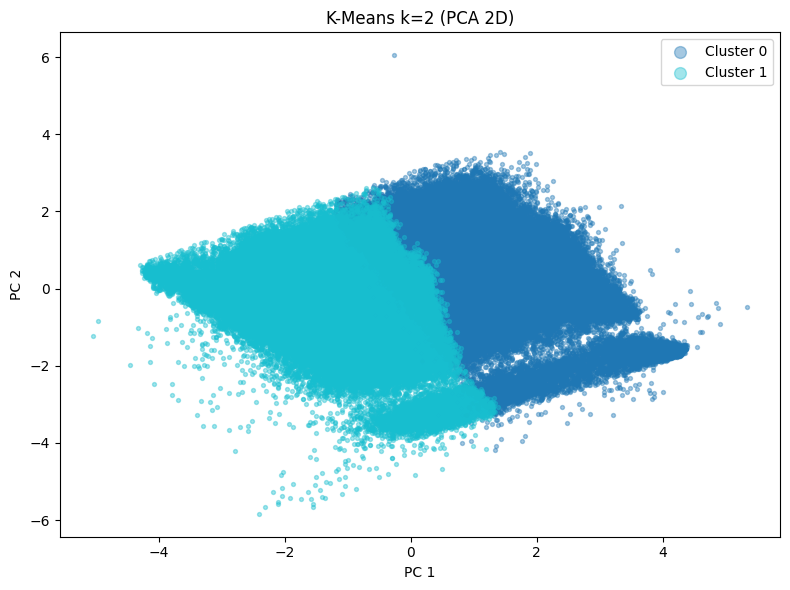

In [7]:
# Таблица размеров / средних return по кластерам (cluster_analysis)
def window_simple_returns(X: np.ndarray, close_idx: int) -> np.ndarray:
    close = X[:, :, close_idx].astype(float)
    return close[:, -1] / (close[:, 0] + 1e-8) - 1.0

ret_train = window_simple_returns(X_train, CLOSE_IDX)
stats_df = cluster_stats(labels_train, returns=ret_train)
display(stats_df)

plot_clusters_2d(train_emb, labels_train, scale=True, title=f"K-Means k={BEST_K} (PCA 2D)")

In [8]:
def window_ends_for_split(
    loader: Dataloader,
    dataset: dict,
    split: str,
    seq_len: int,
    step: int,
    horizon: int = 1,
):
    """Для каждого окна: тикер и timestamp последнего бара окна.
    Порядок строк = concat_splits(dataset). Окна с NaN в y (как в make_windows) пропущены.
    После эмбеддера примени mask_tr: tickers_tr, ts_tr = ...[mask_tr]."""
    tickers_out, ts_out = [], []
    for ticker, splits in dataset.items():
        X_part, y_part = splits[split]
        if len(X_part) == 0:
            continue
        df = loader.load_df(ticker)
        if df is None:
            continue
        df = loader.add_features(df)
        tr, va, te = loader.split_df(df)
        sdf = {"train": tr, "val": va, "test": te}[split]
        if len(sdf) < seq_len + horizon:
            continue
        fcols = [c for c in FEATURE_COLS if c in sdf.columns]
        if "close" not in fcols:
            fcols = ["close"] + fcols
        close_all = sdf["close"].values.astype(np.float32)
        collected = []
        for start in range(0, len(sdf) - seq_len - horizon + 1, step):
            end = start + seq_len
            close_last = close_all[end - 1]
            close_next = close_all[end - 1 + horizon]
            target = (
                np.log(close_next / close_last)
                if close_last > 0 and close_next > 0
                else np.nan
            )
            if not np.isnan(target):
                collected.append((ticker, sdf.index[end - 1]))
        if len(collected) != len(X_part):
            raise RuntimeError(
                f"Mismatch {ticker} {split}: windows {len(X_part)} vs meta {len(collected)}"
            )
        for t, ts in collected:
            tickers_out.append(t)
            ts_out.append(ts)
    return np.array(tickers_out, dtype=object), np.array(ts_out)


tickers_tr, ts_tr = window_ends_for_split(
    loader, dataset, "train", WINDOW_SIZE, STEP
)
# X_train / labels_train после clean_mask короче полного concat_splits
assert len(tickers_tr) == len(mask_tr)
tickers_tr, ts_tr = tickers_tr[mask_tr], ts_tr[mask_tr]
assert len(tickers_tr) == len(labels_train) == len(X_train)
print(f"Metadata train: {len(ts_tr)} window ends (после mask_tr, как X_train)")

AssertionError: 

In [ ]:
# Интерпретация: ClusterAnalyzer (метрики + графики)
# X_metrics = Z — то же масштабирование, что внутри KMeansClusterer (StandardScaler на train)
Z_train = StandardScaler().fit_transform(train_emb)
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d = pca_vis.fit_transform(Z_train)

analyzer = ClusterAnalyzer(
    labels=labels_train,
    windows=X_train,
    embeddings=train_emb,
    timestamps=ts_tr,
    tickers=tickers_tr,
    close_idx=CLOSE_IDX,
    feature_names=FEATURE_COLS,
)

figs = analyzer.run_all(
    embeddings_2d=emb_2d,
    X_metrics=Z_train,
    max_tickers=8,
    aggregate_temporal=True,
)
plt.show()